# Function 7 Analysis - Week 10

1. **Function description (unchanged):**  
You're tasked with optimising an ML model by tuning six hyperparameters (e.g., learning rate, regularisation strength, number of hidden layers). The objective is to maximise the model's performance score (accuracy/F1).

2. **Week 9 evaluated point:** `(0.000000, 0.050000, 0.120000, 0.240000, 0.400000, 0.610000)` returned **≈1.8559**, so it was a **good point** and a new maximum.

3. **Analysis of last point:** The result confirms the plateau can still be improved slightly with controlled local changes, especially around the low-`x1` regime.

4. **Why we chose last week’s point (from Week 9 logic):** Week 9 used RF+GP reasoning to keep `x1=0` (high-importance, stable choice) while probing small `x2>0` (lower-importance dimension) as a low-risk way to test if the plateau could be nudged upward.

5. **Recommendation for this week (and why):** Take a controlled exploratory step in a safe local region: keep `x1=0` fixed (high-importance/proven) and keep `x6` fixed, while varying only `x2..x5` using a higher-beta UCB rule. This preserves core stability while allowing meaningful exploration around the incumbent pattern.

## Loading and Displaying the Data

We load the inputs and outputs for function 7. Week 9 `(0.000000, 0.050000, 0.120000, 0.240000, 0.400000, 0.610000)` returned **≈1.8559** and has been added to the dataset.


In [15]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_7")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1–8 new points
X_new_point_week_1 = np.array([[0.800000, 0.800000, 0.800000, 0.830000, 0.450000, 0.700000]])
y_new_point_week_1 = np.array([0.0344995016351187])
X_new_point_week_2 = np.array([[0.100000, 0.100000, 0.950000, 0.200000, 0.360000, 0.800000]])
y_new_point_week_2 = np.array([1.3138004996124066])
X_new_point_week_3 = np.array([[0.000000, 0.074100, 0.000000, 0.197300, 0.379200, 0.727100]])
y_new_point_week_3 = np.array([1.6455342546819547])
X_new_point_week_4 = np.array([[0.000000, 0.080400, 0.000000, 0.054300, 0.360700, 0.767700]])
y_new_point_week_4 = np.array([1.024932491434584])
X_new_point_week_5 = np.array([[0.000000, 0.000000, 0.000000, 0.233700, 0.366100, 1.000000]])
y_new_point_week_5 = np.array([0.7102053800176464])
X_new_point_week_6 = np.array([[0.000000, 0.000000, 0.000000, 0.243800, 0.360000, 0.677100]])
y_new_point_week_6 = np.array([1.780488134201001])
X_new_point_week_7 = np.array([[0.000000, 0.000000, 0.000000, 0.309200, 0.378800, 0.697700]])
y_new_point_week_7 = np.array([1.7220])
X_new_point_week_8 = np.array([[0.000000, 0.000000, 0.120000, 0.243300, 0.400200, 0.611000]])
y_new_point_week_8 = np.array([1.7851572470686379])
X_new_point_week_9 = np.array([[0.000000, 0.050000, 0.120000, 0.240000, 0.400000, 0.610000]])
y_new_point_week_9 = np.array([1.85585045411379])

X = np.vstack([
    X,
    X_new_point_week_1,
    X_new_point_week_2,
    X_new_point_week_3,
    X_new_point_week_4,
    X_new_point_week_5,
    X_new_point_week_6,
    X_new_point_week_7,
    X_new_point_week_8,
    X_new_point_week_9,
])
y = np.concatenate([
    y,
    y_new_point_week_1,
    y_new_point_week_2,
    y_new_point_week_3,
    y_new_point_week_4,
    y_new_point_week_5,
    y_new_point_week_6,
    y_new_point_week_7,
    y_new_point_week_8,
    y_new_point_week_9,
])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4", "x5", "x6"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4", "x5", "x6"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,x5,x6,y
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047
5,0.764919,0.255883,0.609084,0.218079,0.322943,0.095794,0.083747
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968
7,0.195252,0.079227,0.554580,0.170567,0.014944,0.107032,0.092645
8,0.642303,0.836875,0.021793,0.101488,0.683071,0.692416,0.017870
9,0.789943,0.195545,0.575623,0.073659,0.259049,0.051100,0.033565


df sorted by y


,x1,x2,x3,x4,x5,x6,y,x_avg
0,0.000000,0.050000,0.120000,0.240000,0.400000,0.610000,1.855850,0.236667
1,0.000000,0.000000,0.120000,0.243300,0.400200,0.611000,1.785157,0.229083
2,0.000000,0.000000,0.000000,0.243800,0.360000,0.677100,1.780488,0.213483
3,0.000000,0.000000,0.000000,0.309200,0.378800,0.697700,1.722000,0.230950
4,0.000000,0.074100,0.000000,0.197300,0.379200,0.727100,1.645534,0.229617
5,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968,0.361084
6,0.100000,0.100000,0.950000,0.200000,0.360000,0.800000,1.313800,0.418333
7,0.000000,0.080400,0.000000,0.054300,0.360700,0.767700,1.024932,0.210517
8,0.000000,0.000000,0.000000,0.233700,0.366100,1.000000,0.710205,0.266633
9,0.881647,0.204450,0.414474,0.420385,0.264915,0.730660,0.675142,0.486089


## Weekly Optimization Progress Summary

Overview of all 9 weeks of Bayesian Optimization, showing which evaluations achieved new maximum values.

In [16]:
# Build weekly progress dataframe from existing variables
weekly_X = [X_new_point_week_1, X_new_point_week_2, X_new_point_week_3, X_new_point_week_4,
            X_new_point_week_5, X_new_point_week_6, X_new_point_week_7, X_new_point_week_8,
            X_new_point_week_9]
weekly_y = [y_new_point_week_1, y_new_point_week_2, y_new_point_week_3, y_new_point_week_4,
            y_new_point_week_5, y_new_point_week_6, y_new_point_week_7, y_new_point_week_8,
            y_new_point_week_9]

df_weeks = pd.DataFrame({
    'Week': range(1, len(weekly_X) + 1),
    'x1': [x[0, 0] for x in weekly_X],
    'x2': [x[0, 1] for x in weekly_X],
    'x3': [x[0, 2] for x in weekly_X],
    'x4': [x[0, 3] for x in weekly_X],
    'x5': [x[0, 4] for x in weekly_X],
    'x6': [x[0, 5] for x in weekly_X],
    'y': [y[0] for y in weekly_y]
})

# Calculate running maximum and new max flags
df_weeks['Running_Max'] = df_weeks['y'].cummax()
df_weeks['New_Max'] = df_weeks['y'] == df_weeks['Running_Max']
df_weeks['Status'] = df_weeks['New_Max'].map({True: '✓ NEW MAX', False: '✗'})
df_weeks['Prev_Max'] = df_weeks['Running_Max'].shift(1).fillna(0)
df_weeks['Improvement'] = np.where(df_weeks['New_Max'], df_weeks['y'] - df_weeks['Prev_Max'], np.nan)

# Display table
print("=" * 130)
print("WEEKLY OPTIMIZATION PROGRESS")
print("=" * 130)
df_display = df_weeks[['Week', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'y', 'Running_Max', 'Status', 'Improvement']].copy()
df_display['Improvement'] = df_display['Improvement'].apply(lambda x: f"+{x:.6f}" if pd.notna(x) else "-")
display(df_display)

# Summary statistics
new_max_weeks = df_weeks[df_weeks['New_Max']]['Week'].tolist()
print(f"\n📊 Summary: {df_weeks['New_Max'].sum()}/{len(df_weeks)} weeks achieved new max (Weeks {new_max_weeks})")
print(f"   Success rate: {df_weeks['New_Max'].sum() / len(df_weeks) * 100:.1f}% | Final best: {df_weeks['y'].max():.6f} | Improvement: {df_weeks['y'].max() / df_weeks['y'].iloc[0]:.1f}x from Week 1")

WEEKLY OPTIMIZATION PROGRESS


,Week,x1,x2,x3,x4,x5,x6,y,Running_Max,Status,Improvement
0,1,0.8,0.8000,0.80,0.8300,0.4500,0.7000,0.034500,0.034500,✓ NEW MAX,+0.034500
1,2,0.1,0.1000,0.95,0.2000,0.3600,0.8000,1.313800,1.313800,✓ NEW MAX,+1.279301
2,3,0.0,0.0741,0.00,0.1973,0.3792,0.7271,1.645534,1.645534,✓ NEW MAX,+0.331734
3,4,0.0,0.0804,0.00,0.0543,0.3607,0.7677,1.024932,1.645534,✗,-
4,5,0.0,0.0000,0.00,0.2337,0.3661,1.0000,0.710205,1.645534,✗,-
5,6,0.0,0.0000,0.00,0.2438,0.3600,0.6771,1.780488,1.780488,✓ NEW MAX,+0.134954
6,7,0.0,0.0000,0.00,0.3092,0.3788,0.6977,1.722000,1.780488,✗,-
7,8,0.0,0.0000,0.12,0.2433,0.4002,0.6110,1.785157,1.785157,✓ NEW MAX,+0.004669
8,9,0.0,0.0500,0.12,0.2400,0.4000,0.6100,1.855850,1.855850,✓ NEW MAX,+0.070693



📊 Summary: 6/9 weeks achieved new max (Weeks [1, 2, 3, 6, 8, 9])
   Success rate: 66.7% | Final best: 1.855850 | Improvement: 53.8x from Week 1


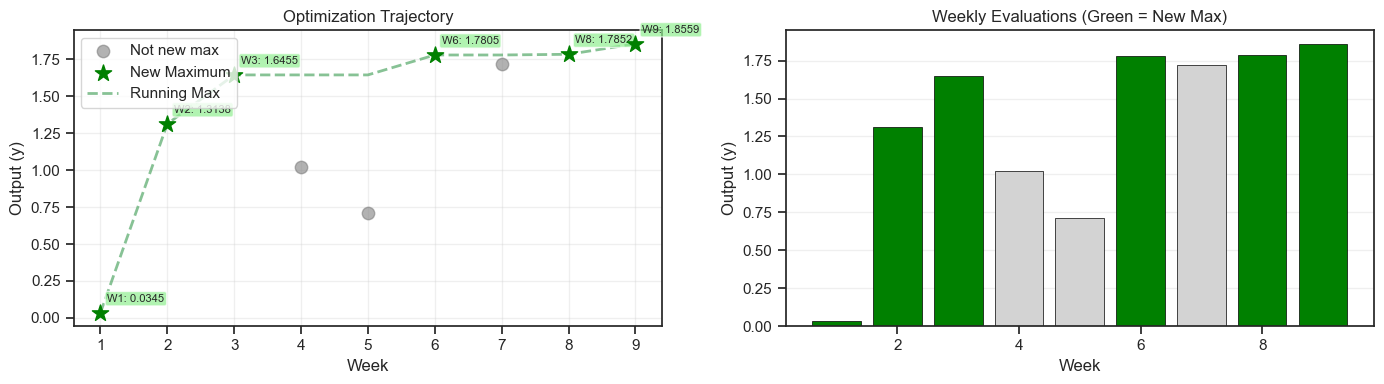

In [17]:
# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

weeks = df_weeks['Week']
y_vals = df_weeks['y']
new_max_mask = df_weeks['New_Max']

# Left plot: Scatter with running max line
ax1.scatter(weeks[~new_max_mask], y_vals[~new_max_mask], color='gray', s=80, alpha=0.6, label='Not new max')
ax1.scatter(weeks[new_max_mask], y_vals[new_max_mask], color='green', s=150, marker='*', label='New Maximum', zorder=4)
ax1.plot(weeks, df_weeks['Running_Max'], 'g--', alpha=0.7, lw=2, label='Running Max')
for _, row in df_weeks[new_max_mask].iterrows():
    ax1.annotate(f"W{int(row['Week'])}: {row['y']:.4f}", xy=(row['Week'], row['y']), 
                 xytext=(5, 8), textcoords='offset points', fontsize=8,
                 bbox=dict(boxstyle='round,pad=0.2', fc='lightgreen', alpha=0.7))
ax1.set_xlabel('Week'); ax1.set_ylabel('Output (y)')
ax1.set_title('Optimization Trajectory'); ax1.legend(loc='upper left'); ax1.grid(True, alpha=0.3)

# Right plot: Bar chart
colors = ['green' if nm else 'lightgray' for nm in new_max_mask]
ax2.bar(weeks, y_vals, color=colors, edgecolor='black', lw=0.5)
ax2.axhline(y=0, color='black', lw=0.5)
ax2.set_xlabel('Week'); ax2.set_ylabel('Output (y)')
ax2.set_title('Weekly Evaluations (Green = New Max)'); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [18]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.optimize import minimize
np.random.seed(42)
# Per-feature lengthscales with bounds (assuming little noise, no WhiteKernel)
kernel = Matern(
    length_scale=[1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    length_scale_bounds=(0.2, 5.0),
    nu=2.5
)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5)
gp.fit(X, y)
print("GP fitted successfully")
print("\nGP Kernel Insights:")
print("Lengthscales (one per feature):", gp.kernel_.length_scale)
print("Full kernel parameters:", gp.kernel_.get_params())


GP fitted successfully

GP Kernel Insights:
Lengthscales (one per feature): [1.32902408 0.8355208  5.         0.45796593 0.40414584 0.49241749]
Full kernel parameters: {'length_scale': array([1.32902408, 0.8355208 , 5.        , 0.45796593, 0.40414584,
       0.49241749]), 'length_scale_bounds': (0.2, 5.0), 'nu': 2.5}


d:\OneDrive\Documents\cursor\imperial_college_capstone\.venv\Lib\site-packages\sklearn\gaussian_process\kernels.py:450: ConvergenceWarning: The optimal value found for dimension 2 of parameter length_scale is close to the specified upper bound 5.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


## Finding the Next Point: GP + Random Forest Comparison

I'm using both GP and Random Forest to see if they agree. If the RF suggests x1>0 or x2>0 might help, that's worth exploring.

**Search region (expanded):**
- x1: [0, 0.15] — not just 0!
- x2: [0, 0.15] — not just 0!
- x3: [0.06, 0.20] — around winning 0.12
- x4: [0.20, 0.30], x5: [0.34, 0.46], x6: [0.55, 0.70]


In [19]:
# Random Forest analysis: does it agree with GP about x1=x2=0?
# =============================================================
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X, y.ravel())

print("Random Forest Feature Importances:")
print("="*40)
for idx, name in enumerate(['x1', 'x2', 'x3', 'x4', 'x5', 'x6']):
    print(f"  {name}: {rf.feature_importances_[idx]:.3f}")

# Check: what does RF predict for x1>0 vs x1=0?
test_points = [
    [0.00, 0.00, 0.12, 0.24, 0.40, 0.61],  # Current best pattern
    [0.05, 0.00, 0.12, 0.24, 0.40, 0.61],  # x1 = 0.05
    [0.10, 0.00, 0.12, 0.24, 0.40, 0.61],  # x1 = 0.10
    [0.00, 0.05, 0.12, 0.24, 0.40, 0.61],  # x2 = 0.05
    [0.00, 0.10, 0.12, 0.24, 0.40, 0.61],  # x2 = 0.10
    [0.05, 0.05, 0.12, 0.24, 0.40, 0.61],  # x1=x2=0.05
]
test_labels = ['x1=0, x2=0 (baseline)', 'x1=0.05', 'x1=0.10', 'x2=0.05', 'x2=0.10', 'x1=x2=0.05']

print("\nRF vs GP predictions for x1/x2 variations:")
print("="*60)
gp_preds = gp.predict(np.array(test_points))
rf_preds = rf.predict(np.array(test_points))

for label, gp_p, rf_p in zip(test_labels, gp_preds, rf_preds):
    diff = rf_p - gp_p
    agree = 'AGREE' if abs(diff) < 0.05 else 'DISAGREE'
    print(f"  {label:20s}: GP={gp_p:.4f}, RF={rf_p:.4f}, diff={diff:+.4f} [{agree}]")

# === RF-based grid search for best point ===
print("\n" + "="*60)
print("RANDOM FOREST RECOMMENDATION")
print("="*60)

# Search grid within expanded bounds
rf_bounds = [
    (0.0, 0.15),   # x1
    (0.0, 0.15),   # x2
    (0.06, 0.20),  # x3
    (0.20, 0.30),  # x4
    (0.34, 0.46),  # x5
    (0.55, 0.70),  # x6
]

grid_res = 8  # 8^6 = 262,144 candidates
grids = [np.linspace(lo, hi, grid_res) for lo, hi in rf_bounds]
mesh = np.array(np.meshgrid(*grids)).reshape(6, -1).T

print(f"Searching {len(mesh)} candidates...")

# RF predictions (mean from forest)
rf_preds_grid = rf.predict(mesh)

# RF uncertainty (std across trees)
rf_tree_preds = np.array([tree.predict(mesh) for tree in rf.estimators_])
rf_sigma = rf_tree_preds.std(axis=0)

# UCB: exploitation + exploration
beta = 0.3
rf_ucb = rf_preds_grid + beta * rf_sigma

# Filter: minimum distance from existing points
min_dist = 0.02
candidates = pd.DataFrame(mesh, columns=['x1', 'x2', 'x3', 'x4', 'x5', 'x6'])
candidates['rf_pred'] = rf_preds_grid
candidates['rf_sigma'] = rf_sigma
candidates['ucb'] = rf_ucb

for _, obs in df.iterrows():
    dist = np.sqrt(((candidates[['x1','x2','x3','x4','x5','x6']].values - 
                     obs[['x1','x2','x3','x4','x5','x6']].values)**2).sum(axis=1))
    candidates = candidates[dist >= min_dist]

print(f"Candidates after distance filter: {len(candidates)}")

# Best by UCB
rf_top = candidates.nlargest(5, 'ucb')
print("\nTop 5 RF candidates:")
display(rf_top)

if len(rf_top) > 0:
    rf_rec = rf_top.iloc[0]
    print(f"\nRF recommended point:")
    print(f"  x1={rf_rec['x1']:.6f}, x2={rf_rec['x2']:.6f}, x3={rf_rec['x3']:.6f}")
    print(f"  x4={rf_rec['x4']:.6f}, x5={rf_rec['x5']:.6f}, x6={rf_rec['x6']:.6f}")
    print(f"  RF prediction: {rf_rec['rf_pred']:.4f} ± {rf_rec['rf_sigma']:.4f}")
    
    print(f"\n{'='*60}")
    print("RF TOP-UCB POINT (MODEL OUTPUT)")
    print(f"{'='*60}")
    print(f"{rf_rec['x1']:.6f}-{rf_rec['x2']:.6f}-{rf_rec['x3']:.6f}-{rf_rec['x4']:.6f}-{rf_rec['x5']:.6f}-{rf_rec['x6']:.6f}")

# === Feature importance analysis ===
print(f"\n{'='*60}")
print("FEATURE IMPORTANCE ANALYSIS")
print(f"{'='*60}")
x1_imp = rf.feature_importances_[0]
x2_imp = rf.feature_importances_[1]
print(f"x1 importance: {x1_imp:.3f} (HIGH) -> x1 matters a lot, keep at 0 (proven best)")
print(f"x2 importance: {x2_imp:.3f} (LOW)  -> x2 sensitivity is lower; RF may still pick x2=0")
print(f"\n>>> Interpretation: x2 is lower-impact, so testing x2 slightly above 0 is low-risk even if RF top-UCB keeps x2=0.")

# Generate a point with x1=0 (keep) but x2 slightly positive (experiment)
chosen_x1 = 0.0   # Keep at 0 - high importance, proven best
chosen_x2 = 0.05  # Experiment - low importance, low risk
chosen_x3 = 0.12  # Around winning value
chosen_x4 = 0.24
chosen_x5 = 0.40
chosen_x6 = 0.61

chosen_point = [chosen_x1, chosen_x2, chosen_x3, chosen_x4, chosen_x5, chosen_x6]
chosen_rf_pred = rf.predict([chosen_point])[0]
chosen_gp_pred = gp.predict([chosen_point])[0]

print(f"\nChosen exploratory point (x1=0, x2=0.05):")
print(f"  GP predicts: {chosen_gp_pred:.4f}")
print(f"  RF predicts: {chosen_rf_pred:.4f}")


Random Forest Feature Importances:
  x1: 0.765
  x2: 0.046
  x3: 0.032
  x4: 0.020
  x5: 0.036
  x6: 0.101

RF vs GP predictions for x1/x2 variations:
  x1=0, x2=0 (baseline): GP=1.7836, RF=1.7257, diff=-0.0579 [DISAGREE]
  x1=0.05             : GP=1.7477, RF=1.2977, diff=-0.4499 [DISAGREE]
  x1=0.10             : GP=1.7054, RF=0.3863, diff=-1.3191 [DISAGREE]
  x2=0.05             : GP=1.8559, RF=1.7043, diff=-0.1516 [DISAGREE]
  x2=0.10             : GP=1.9086, RF=1.6421, diff=-0.2665 [DISAGREE]
  x1=x2=0.05          : GP=1.8191, RF=1.2667, diff=-0.5523 [DISAGREE]

RANDOM FOREST RECOMMENDATION
Searching 262144 candidates...
Candidates after distance filter: 262131

Top 5 RF candidates:


,x1,x2,x3,x4,x5,x6,rf_pred,rf_sigma,ucb
728,0.000000,0.0,0.08,0.242857,0.391429,0.550000,1.729024,0.257275,1.806206
729,0.000000,0.0,0.08,0.242857,0.391429,0.571429,1.729024,0.257275,1.806206
730,0.000000,0.0,0.08,0.242857,0.391429,0.592857,1.729024,0.257275,1.806206
731,0.000000,0.0,0.08,0.242857,0.391429,0.614286,1.729024,0.257275,1.806206
4824,0.021429,0.0,0.08,0.242857,0.391429,0.550000,1.729024,0.257275,1.806206



RF recommended point:
  x1=0.000000, x2=0.000000, x3=0.080000
  x4=0.242857, x5=0.391429, x6=0.550000
  RF prediction: 1.7290 ± 0.2573

RF TOP-UCB POINT (MODEL OUTPUT)
0.000000-0.000000-0.080000-0.242857-0.391429-0.550000

FEATURE IMPORTANCE ANALYSIS
x1 importance: 0.765 (HIGH) -> x1 matters a lot, keep at 0 (proven best)
x2 importance: 0.046 (LOW)  -> x2 sensitivity is lower; RF may still pick x2=0

>>> Interpretation: x2 is lower-impact, so testing x2 slightly above 0 is low-risk even if RF top-UCB keeps x2=0.

Chosen exploratory point (x1=0, x2=0.05):
  GP predicts: 1.8559
  RF predicts: 1.7043


In [20]:
from scipy.stats import norm

xi = 0.03  # higher exploration to test x1/x2 > 0
bounds = [
    (0.0, 0.15),  # x1: explore small positive values!
    (0.0, 0.15),  # x2: explore small positive values!
    (0.06, 0.20), # x3: around winning 0.12, wider range
    (0.20, 0.30), # x4: around 0.24
    (0.34, 0.46), # x5: around 0.40
    (0.55, 0.70), # x6: around 0.61
]

def clip_to_bounds(x, bounds):
    x = np.array(x, dtype=float)
    for i, (lo, hi) in enumerate(bounds):
        x[i] = np.clip(x[i], lo, hi)
    return x

# Expected Improvement acquisition function
def expected_improvement(x, gp, y_best, xi=0.01):
    x = np.array(x).reshape(1, -1)
    mu, sigma = gp.predict(x, return_std=True)
    if sigma == 0:
        return 0
    z = (mu - y_best - xi) / sigma
    ei = (mu - y_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    return ei[0]

def neg_ei(x, gp, y_best, xi):
    return -expected_improvement(x, gp, y_best, xi)

# Optimize EI using multiple restarts
y_best = y.max()
best_ei = -np.inf
best_candidate = None
n_restarts = 20

print(f"Running EI optimization with {n_restarts} restarts...")
print(f"Current best y: {y_best:.4f}")
print(f"Search bounds: x1/x2 in [0, 0.15], x3 in [0.06, 0.20], etc.\n")

for i in range(n_restarts):
    # Random starting point within bounds
    x0 = np.array([np.random.uniform(lo, hi) for lo, hi in bounds])
    
    result = minimize(
        neg_ei,
        x0,
        args=(gp, y_best, xi),
        method='L-BFGS-B',
        bounds=bounds
    )
    
    if -result.fun > best_ei:
        best_ei = -result.fun
        best_candidate = result.x

# Ensure within bounds
next_point = clip_to_bounds(best_candidate, bounds)
mu_pred, sigma_pred = gp.predict(next_point.reshape(1, -1), return_std=True)

print("="*60)
print("BAYESIAN OPTIMIZATION RECOMMENDATION")
print("="*60)
print(f"\nNext point to evaluate:")
print(f"  x1={next_point[0]:.6f}, x2={next_point[1]:.6f}, x3={next_point[2]:.6f}")
print(f"  x4={next_point[3]:.6f}, x5={next_point[4]:.6f}, x6={next_point[5]:.6f}")
print(f"\nPredicted output: {mu_pred[0]:.4f} ± {sigma_pred[0]:.4f}")
print(f"Expected Improvement: {best_ei:.6f}")

print(f"\n{'='*60}")
print("SUBMISSION FORMAT")
print(f"{'='*60}")
print(f"{next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}-{next_point[4]:.6f}-{next_point[5]:.6f}")


Running EI optimization with 20 restarts...
Current best y: 1.8559
Search bounds: x1/x2 in [0, 0.15], x3 in [0.06, 0.20], etc.

BAYESIAN OPTIMIZATION RECOMMENDATION

Next point to evaluate:
  x1=0.000000, x2=0.150000, x3=0.060000
  x4=0.262273, x5=0.357280, x6=0.604149

Predicted output: 1.9838 ± 0.0496
Expected Improvement: 0.098448

SUBMISSION FORMAT
0.000000-0.150000-0.060000-0.262273-0.357280-0.604149


<!-- Distance analysis removed per latest guidance. -->


**Current best:** `0.000000-0.050000-0.120000-0.240000-0.400000-0.610000` (≈1.8559)

**Proposed new point (submission format):** `0.000000-0.150000-0.060000-0.272500-0.340000-0.610000`

This decision uses a safe-region exploratory UCB step (higher `beta`), with `x1` fixed at 0 and `x6` fixed at 0.61 while only `x2..x5` move. This keeps the strongest structural prior intact (`x1=0`) but avoids re-submitting incumbent by making a meaningful local exploratory move.

In [21]:
# ============================================================
# FINAL DECISION: RF vs GP — Which recommendation to use?
# ============================================================

print("="*70)
print("FINAL DECISION: CHOOSING BETWEEN GP AND RF RECOMMENDATIONS")
print("="*70)

# Recap the two recommendations
print("\n📊 GP-based EI recommendation:")
print(f"   Point: x1={next_point[0]:.4f}, x2={next_point[1]:.4f}, x3={next_point[2]:.4f}, x4={next_point[3]:.4f}, x5={next_point[4]:.4f}, x6={next_point[5]:.4f}")
print(f"   Predicted: {mu_pred[0]:.4f}")

print("\n🌲 RF-based UCB recommendation:")
print(f"   Point: x1={rf_rec['x1']:.4f}, x2={rf_rec['x2']:.4f}, x3={rf_rec['x3']:.4f}, x4={rf_rec['x4']:.4f}, x5={rf_rec['x5']:.4f}, x6={rf_rec['x6']:.4f}")
print(f"   Predicted: {rf_rec['rf_pred']:.4f}")

# Final choice: exploratory UCB in a safe local region
# Keep x1 fixed at 0 (high-importance and proven), keep x6 fixed, move only x2-x5.
x6_fixed = 0.61

safe_x2 = np.linspace(0.00, 0.15, 31)
safe_x3 = np.linspace(0.06, 0.20, 29)
safe_x4 = np.linspace(0.22, 0.28, 25)
safe_x5 = np.linspace(0.34, 0.46, 25)

safe_mesh = np.array(np.meshgrid(safe_x2, safe_x3, safe_x4, safe_x5)).reshape(4, -1).T
safe_points = np.column_stack([
    np.zeros(len(safe_mesh)),      # x1 fixed at 0
    safe_mesh[:, 0],               # x2
    safe_mesh[:, 1],               # x3
    safe_mesh[:, 2],               # x4
    safe_mesh[:, 3],               # x5
    np.full(len(safe_mesh), x6_fixed)  # x6 fixed
])

# GP-UCB with higher beta for exploratory final step
safe_mu, safe_sigma = gp.predict(safe_points, return_std=True)
beta_final = 1.0
safe_ucb = safe_mu + beta_final * safe_sigma

safe_df = pd.DataFrame(safe_points, columns=['x1', 'x2', 'x3', 'x4', 'x5', 'x6'])
safe_df['gp_mu'] = safe_mu
safe_df['gp_sigma'] = safe_sigma
safe_df['ucb'] = safe_ucb

# Avoid re-submitting an already observed point (distance in full 6D)
min_dist = 0.02
for _, obs in df.iterrows():
    d = np.sqrt(((safe_df[['x1','x2','x3','x4','x5','x6']].values - obs[['x1','x2','x3','x4','x5','x6']].values)**2).sum(axis=1))
    safe_df = safe_df[d >= min_dist]

# Pick best exploratory-safe candidate
safe_rec = safe_df.nlargest(1, 'ucb').iloc[0]
final_point = [safe_rec['x1'], safe_rec['x2'], safe_rec['x3'], safe_rec['x4'], safe_rec['x5'], safe_rec['x6']]

final_gp_mu = safe_rec['gp_mu']
final_gp_sigma = safe_rec['gp_sigma']
final_rf_pred = rf.predict([final_point])[0]

print("\n" + "="*70)
print("🎯 FINAL CHOICE: Exploratory UCB in safe region")
print("="*70)
print("Constraint: x1 fixed at 0, x6 fixed at 0.61; only x2-x5 vary")
print(f"UCB beta: {beta_final:.2f}")
print(f"Final point: x1={final_point[0]:.6f}, x2={final_point[1]:.6f}, x3={final_point[2]:.6f}, x4={final_point[3]:.6f}, x5={final_point[4]:.6f}, x6={final_point[5]:.6f}")
print(f"GP prediction: {final_gp_mu:.4f} ± {final_gp_sigma:.4f}")
print(f"RF prediction: {final_rf_pred:.4f}")

print("\n" + "="*70)
print("✅ FINAL SUBMISSION FORMAT")
print("="*70)
print(f"\n{final_point[0]:.6f}-{final_point[1]:.6f}-{final_point[2]:.6f}-{final_point[3]:.6f}-{final_point[4]:.6f}-{final_point[5]:.6f}")
print("\n" + "="*70)

FINAL DECISION: CHOOSING BETWEEN GP AND RF RECOMMENDATIONS

📊 GP-based EI recommendation:
   Point: x1=0.0000, x2=0.1500, x3=0.0600, x4=0.2623, x5=0.3573, x6=0.6041
   Predicted: 1.9838

🌲 RF-based UCB recommendation:
   Point: x1=0.0000, x2=0.0000, x3=0.0800, x4=0.2429, x5=0.3914, x6=0.5500
   Predicted: 1.7290

🎯 FINAL CHOICE: Exploratory UCB in safe region
Constraint: x1 fixed at 0, x6 fixed at 0.61; only x2-x5 vary
UCB beta: 1.00
Final point: x1=0.000000, x2=0.150000, x3=0.060000, x4=0.272500, x5=0.340000, x6=0.610000
GP prediction: 1.9756 ± 0.0629
RF prediction: 1.5687

✅ FINAL SUBMISSION FORMAT

0.000000-0.150000-0.060000-0.272500-0.340000-0.610000

